# W1D5 — Clustering & PCA — Lab

**Week 1 · Day 5 · Foundations** · Lab

Every lab this week could tell you whether you were right. This one cannot. There is no label in the
file, no accuracy to compute, and no assert that can say your answer is wrong — so the deliverable stops
being a score and becomes an **argument**. You will run K-Means by hand on the six points from this
morning, cluster 4,372 real customers twice (once on raw columns, where it goes badly, and once
standardised), watch the elbow and the silhouette disagree with each other and with common sense, choose
a `k` and defend it in writing from the cluster profiles, and finish with a 2-D PCA picture that
explains less than half of what is in the data.

You leave with `segments.parquet` and `pca_2d.png`.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٥ — التجميع وتحليل المكوّنات الرئيسة

**الأسبوع ١ · اليوم ٥ · الأساسيات** · معمل عملي

كل معامل هذا الأسبوع كان بوسعه أن يخبرك هل أصبت. وهذا المعمل لا يستطيع. لا تسمية في الملف، ولا دقّة
تُحسب، ولا فحص يستطيع أن يقول إن إجابتك خاطئة — ومن ثمّ يتوقّف المُخرَج عن كونه درجة ويصير **حجّة**.
ستنفّذ K-Means يدويًا على النقاط الست من هذا الصباح، وتجمّع ٤٬٣٧٢ عميلًا حقيقيًا مرتين (مرة على الأعمدة
الخام حيث يسوء الأمر، ومرة بعد التوحيد القياسي)، وتشاهد الكوع ومعامل الظلّ يختلفان أحدهما مع الآخر ومع
المنطق، ثم تختار `k` وتدافع عنها كتابةً من ملامح العناقيد، وتختم بصورة ثنائية البعد من PCA تفسّر أقل من
نصف ما في البيانات.

وستخرج بملفَّي `segments.parquet` و`pca_2d.png`.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Run one round of K-Means by hand — assign, update — and say why a point changes group.
- Show what unscaled columns do to a distance-based algorithm, and what standardising does and does not fix.
- Read an elbow plot and a silhouette score, and say what to do when they disagree.
- Choose a `k` from cluster profiles and defend the choice in writing.
- State what a 2-D PCA scatter of a 12-column dataset is, and is not, evidence of.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- تنفيذ جولة واحدة من K-Means يدويًا — إسناد ثم تحديث — وبيان سبب انتقال نقطة من مجموعة إلى أخرى.
- إظهار أثر الأعمدة غير الموحّدة على خوارزمية قائمة على المسافة، وما الذي يصلحه التوحيد القياسي وما لا يصلحه.
- قراءة رسم الكوع ومعامل الظلّ، وتحديد ما تفعله حين يختلفان.
- اختيار `k` من ملامح العناقيد والدفاع عن الاختيار كتابةً.
- تحديد ما يدلّ عليه وما لا يدلّ عليه مخطّط PCA ثنائي البعد لمجموعة بيانات بـ١٢ عمودًا.

</div>

## About the data

**Dataset:** `customer_segments` — UK online-retail transactions aggregated to customer level · CC0 ·
4,372 rows

One row is one customer, summarised across a year of orders into **12 numeric columns and no label**:
how many orders they placed, how many distinct products they bought, what they spent in total, their
average and largest order, how recently they bought, how long they have been active, and how much of
their buying came back as returns. The absence of a label is not an oversight. It is the reason the day
exists: there is nothing here to predict, so the only question available is "are there groups, and what
would I do with them?"

**Watch out:** the spend columns are **heavily right-skewed**. Total spend has a median of £648 and a
maximum of £279,489 — a handful of wholesale accounts buying at a scale nobody else approaches. K-Means
measures distance, and distance is dominated by whichever column has the largest numbers, so on raw
columns you will get one cluster holding 99% of customers and three holding the outliers. Task 2.2 fixes
most of that. It does not fix all of it, and the part it does not fix is worth more than the part it does.

**One more oddity, and it is real data doing real things:** a few customers have *negative* total spend.
They returned more than they bought. They are kept in the file on purpose — dropping them would tidy away
the long tail that makes this lab work.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `customer_segments` — معاملات متجر بريطاني على الإنترنت مجمّعة على مستوى العميل ·
رخصة CC0 · ٤٬٣٧٢ صفًا

الصف الواحد عميل واحد، ملخَّص عبر سنة من الطلبات في **١٢ عمودًا رقميًا بلا أي تسمية**: كم طلبًا قدّم،
وكم منتجًا مختلفًا اشترى، وكم أنفق إجمالًا، وما متوسّط طلبه وأكبره، ومتى اشترى آخر مرة، ومنذ متى وهو
نشط، وكم من شرائه عاد مرتجعًا. وغياب التسمية ليس سهوًا، بل هو سبب وجود هذا اليوم: لا شيء هنا للتنبّؤ به،
فلا يبقى إلا سؤال واحد: «هل توجد مجموعات، وماذا سأفعل بها؟»

**انتبه:** أعمدة الإنفاق **ملتوية بشدّة نحو اليمين**. فوسيط الإنفاق الإجمالي ٦٤٨ جنيهًا وأقصاه ٢٧٩٬٤٨٩ —
حفنة من حسابات الجملة تشتري بحجم لا يقاربه أحد. وK-Means تقيس المسافة، والمسافة يهيمن عليها العمود ذو
الأرقام الأكبر، فتحصل على الأعمدة الخام على عنقود واحد يضمّ ٩٩٪ من العملاء وثلاثة تضمّ الشواذّ. والمهمة
٢٫٢ تصلح معظم ذلك. لكنها لا تصلحه كلّه، وما لا تصلحه أثمن ممّا تصلحه.

**وغرابة أخيرة، وهي بيانات حقيقية تفعل ما تفعله البيانات الحقيقية:** بعض العملاء إنفاقهم الإجمالي
**سالب**. أرجعوا أكثر ممّا اشتروا. وقد أُبقوا في الملف عمدًا، فحذفهم يُزيل الذيل الطويل الذي يقوم عليه
هذا المعمل.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and finds the dataset —
whether you are on your own machine or on Google Colab.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات — سواء كنت على
جهازك أو على Google Colab.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("customer_segments")
customers = pd.read_parquet(DATA)

FEATURES = [c for c in customers.columns if c != "customer_id"]

print(describe_dataset("customer_segments"))
print(f"\n{customers.shape[0]:,} customers x {len(FEATURES)} numeric features, no label")
print("\n", versions())

📁 customer_segments: using cached file at C:\Users\ACER\AIEP_Olo_student\shared\data_cache\customer_segments.parquet
customer_segments  (4372 rows, 0.17 MB)
  Source:  Retail transactions aggregated to customer level (classroom fixture)
  Licence: CC0
  Target:  None

  EN: Customer-level spending features with no label — clustering has to justify itself without an accuracy score, which is the actual lesson of the day.
  AR: خصائص إنفاق على مستوى العميل بلا تسمية — على التجميع أن يبرّر نفسه دون مقياس دقة، وهذا هو الدرس الحقيقي لليوم.

  ⚠️  Watch out: Spend columns are heavily right-skewed; K-Means on raw values finds one giant cluster and a few outliers.
  ⚠️  انتبه: أعمدة الإنفاق ملتوية بشدة نحو اليمين؛ وتطبيق K-Means على القيم الخام ينتج عنقودًا ضخمًا وبضع قيم شاذّة.

4,372 customers x 12 numeric features, no label

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0+cpu | transformers 5.15.1


## Section 1 — Warm-up: K-Means by hand  (≈25 min)

Guided. The code below works. Run it, read it, then do the two rounds the task asks for.

The six points from this morning, with integer coordinates so you can check every step against your own
notebook:

`A(0,1)` · `B(1,1)` · `C(2,0)` · `D(6,0)` · `E(6,2)` · `F(6,4)`, starting centroids `(0, 1)` and `(2, 0)`.

Nothing here is random. If your numbers differ from the slide, one of you is wrong.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: K-Means يدويًا (نحو ٢٥ دقيقة)

قسم موجَّه. الشيفرة أدناه تعمل. شغّلها واقرأها، ثم نفّذ الجولتين اللتين تطلبهما المهمة.

النقاط الست من هذا الصباح، بإحداثيات صحيحة لتتمكّن من مطابقة كل خطوة بدفترك:

`A(0,1)` · `B(1,1)` · `C(2,0)` · `D(6,0)` · `E(6,2)` · `F(6,4)`، والمركزان الابتدائيان `(0, 1)` و`(2, 0)`.

ولا شيء هنا عشوائي. فإن اختلفت أرقامك عن الشريحة فأحدكما مخطئ.

</div>

In [2]:
# Working code. Nothing to fill in here.
POINTS = np.array([[0, 1], [1, 1], [2, 0], [6, 0], [6, 2], [6, 4]], dtype=float)
NAMES = ["A", "B", "C", "D", "E", "F"]
start_centroids = np.array([[0.0, 1.0], [2.0, 0.0]])


def distances_to(centroids, points=POINTS):
    """Euclidean distance from every point to every centroid: one row per centroid."""
    return np.linalg.norm(points[None, :, :] - centroids[:, None, :], axis=2)


print(pd.DataFrame(distances_to(start_centroids).round(2),
                   index=["to centroid 1", "to centroid 2"],
                   columns=NAMES).to_string())

                  A     B     C     D     E     F
to centroid 1  0.00  1.00  2.24  6.08  6.08  6.71
to centroid 2  2.24  1.41  0.00  4.00  4.47  5.66


Those twelve numbers are the twelve from the slide. Each point joins whichever centroid is nearer, so
group 1 gets A and B, and group 2 gets C, D, E and F.

<div dir="rtl" align="right">

هذه الأرقام الاثنا عشر هي نفسها التي في الشريحة. وتنضمّ كل نقطة إلى المركز الأقرب، فتأخذ المجموعة الأولى
A وB، وتأخذ الثانية C وD وE وF.

</div>

### Task 1.1 — assign, update, and watch C change sides

Do two rounds. In each round: assign every point to its nearest centroid, then move each centroid to the
mean of the points that joined it.

After round 1 the centroids should be at `(0.5, 1.0)` and `(5.0, 1.5)`. In round 2, look at C: it is
1.80 from the first centroid and 3.35 from the second, so it switches. Nothing else moves.

That switch is the algorithm correcting its own first guess. It is the entire idea.

<div dir="rtl" align="right">

### المهمة ١٫١ — أسنِد وحدِّث وراقب انتقال C

نفّذ جولتين. في كل جولة: أسنِد كل نقطة إلى أقرب مركز، ثم انقل كل مركز إلى متوسّط النقاط التي انضمّت إليه.

بعد الجولة الأولى يجب أن يكون المركزان عند `(0.5, 1.0)` و`(5.0, 1.5)`. وفي الجولة الثانية انظر إلى C:
تبعد ١٫٨٠ عن المركز الأول و٣٫٣٥ عن الثاني، فتنتقل. ولا يتحرّك شيء غيرها.

وهذا الانتقال هو تصحيح الخوارزمية لتخمينها الأول. وهو الفكرة كلّها.

</div>

In [4]:
# ────────────────────────────────────────────────────────────────────
# 1) `distances_to(centroids)` gives you one row per centroid. The nearest centroid for each
#    point is the position of the smallest value down each column.
# 2) To update: for each centroid, take the mean of the points assigned to it. Two lines.
# 3) Loop that twice, printing the assignment and the new centroids each round.
# 4) Round 1 must give centroids (0.5, 1.0) and (5.0, 1.5). If it does not, stop and compare
#    with your notebook from this morning before going on.
# Search: "numpy argmin axis assign nearest centroid"
#
# ١) تعطيك `distances_to(centroids)` صفًا لكل مركز. وأقرب مركز لكل نقطة هو موضع أصغر قيمة
#    في عمودها.
# ٢) للتحديث: خذ لكل مركز متوسّط النقاط المُسنَدة إليه. سطران.
# ٣) كرّر ذلك مرتين، واطبع الإسناد والمركزين الجديدين في كل جولة.
# ٤) يجب أن تعطي الجولة الأولى المركزين (0.5, 1.0) و(5.0, 1.5). فإن لم تفعل فتوقّف وقارن
#    بدفترك من هذا الصباح قبل المتابعة.
# ابحث عن: "numpy argmin axis assign nearest centroid"
# ────────────────────────────────────────────────────────────────────

# TODO: Run two rounds of assign-then-update from `start_centroids`, printing each round.
# مهمة: نفّذ جولتين من الإسناد ثم التحديث بدءًا من `start_centroids`، واطبع كل جولة.

centroids = start_centroids.copy()
history = []

for round_num in range(1, 3):
    dists = distances_to(centroids)
    assignment = np.argmin(dists, axis=0)
    history.append(assignment)

    print(f"--- الجولة {round_num} ---")
    for name, a in zip(NAMES, assignment):
        print(f"  {name} -> centroid {a}")

    new_centroids = np.array([
        POINTS[assignment == c].mean(axis=0) for c in range(len(centroids))
    ])
    print(f"  new centroids: {new_centroids.tolist()}\n")

    centroids = new_centroids

moved = [name for name, before, after in zip(NAMES, history[0], history[1]) if before != after]
print(f"points that changed group between round 1 and round 2: {moved}")

--- الجولة 1 ---
  A -> centroid 0
  B -> centroid 0
  C -> centroid 1
  D -> centroid 1
  E -> centroid 1
  F -> centroid 1
  new centroids: [[0.5, 1.0], [5.0, 1.5]]

--- الجولة 2 ---
  A -> centroid 0
  B -> centroid 0
  C -> centroid 0
  D -> centroid 1
  E -> centroid 1
  F -> centroid 1
  new centroids: [[1.0, 0.6666666666666666], [6.0, 2.0]]

points that changed group between round 1 and round 2: ['C']


`C` and only `C`. In round 1 it joined the second centroid because it started at `(2, 0)` — which is
exactly where C is. Then that centroid was dragged right to `(5.0, 1.5)` by D, E and F, leaving C
stranded, so round 2 sent it back.

Two things follow from that, and both matter this afternoon. The starting centroids change the answer,
which is why `KMeans` runs itself several times from different starts and keeps the best. And "nearest"
is measured in whatever units the columns happen to be in — which is the whole of Task 2.1.

<div dir="rtl" align="right">

النقطة `C` وحدها. ففي الجولة الأولى انضمّت إلى المركز الثاني لأنه بدأ عند `(2, 0)`، وهو موضع C تمامًا.
ثم جرّته D وE وF يمينًا إلى `(5.0, 1.5)` فبقيت C وحيدة، فأعادتها الجولة الثانية.

ويتبع ذلك أمران، وكلاهما مهم بعد الظهر. المراكز الابتدائية تغيّر الإجابة، ولهذا تشغّل `KMeans` نفسها عدة
مرات من بدايات مختلفة وتحتفظ بأفضلها. و«الأقرب» تُقاس بالوحدات التي تصادف أن تكون الأعمدة بها — وهذا هو
موضوع المهمة ٢٫١ كلّه.

</div>

## Section 2 — Core: 4,372 customers and no answer key  (≈60 min)

This is the lab. Each task below has a goal; you write the code.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: ٤٬٣٧٢ عميلًا بلا مفتاح إجابة (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة أدناه هدف محدّد، وأنت من يكتب الشيفرة.

</div>

### Task 2.1 — cluster the raw columns, and look at the sizes

Run `KMeans` with `k=4` on the twelve feature columns exactly as they are. Then print how many customers
landed in each cluster.

Do not fix anything yet. Look at the sizes first.

<div dir="rtl" align="right">

### المهمة ٢٫١ — جمّع الأعمدة الخام وانظر إلى الأحجام

شغّل `KMeans` بـ`k=4` على أعمدة الخصائص الاثني عشر كما هي تمامًا. ثم اطبع عدد العملاء في كل عنقود.

لا تصلح شيئًا بعد. انظر إلى الأحجام أولًا.

</div>

In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Build the feature matrix from the FEATURES columns — everything except customer_id.
# 2) KMeans(n_clusters=4, n_init=10, random_state=42). n_init is the several-starts idea
#    from the warm-up; random_state makes your answer the same tomorrow.
# 3) Count the labels, and print each cluster's share of the 4,372 customers, not just its
#    count. A share is what makes the problem visible.
# Search: "sklearn KMeans n_init labels_ numpy bincount"
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
#
# ١) ابنِ مصفوفة الخصائص من أعمدة FEATURES — أي كل شيء عدا customer_id.
# ٢) استخدم KMeans(n_clusters=4, n_init=10, random_state=42). والوسيط n_init هو فكرة تعدّد
#    البدايات من قسم التهيئة، وrandom_state يجعل إجابتك نفسها غدًا.
# ٣) عُدّ التسميات، واطبع نصيب كل عنقود من الـ٤٬٣٧٢ عميلًا لا عدده فقط. فالنصيب هو ما يُظهر
#    المشكلة.
# ابحث عن: "sklearn KMeans n_init labels_ numpy bincount"
# ────────────────────────────────────────────────────────────────────




from sklearn.cluster import KMeans
X_raw = customers[FEATURES].to_numpy(dtype=float)

kmeans_raw = KMeans(n_clusters=4, n_init=10, random_state=42)
raw_labels = kmeans_raw.fit_predict(X_raw)
raw_sizes = np.bincount(raw_labels)

raw_biggest_share = raw_sizes.max() / len(customers)
for cluster, size in enumerate(raw_sizes):
    print(f"cluster {cluster}: {size:>5,} customers  ({size / len(customers):6.2%})")

print(f"\nbiggest cluster holds {raw_biggest_share:.2%} of all customers")

cluster 0: 4,335 customers  (99.15%)
cluster 1:     5 customers  ( 0.11%)
cluster 2:    30 customers  ( 0.69%)
cluster 3:     2 customers  ( 0.05%)

biggest cluster holds 99.15% of all customers


One cluster holds 99% of the customers. The other three hold 5, 30 and 2 people between them.

That is not four segments. It is one segment and three lists of outliers, and it happened because
`total_spend` runs to 279,489 while `n_orders` runs to 248. When you compute a Euclidean distance across
those twelve columns, `total_spend` and `n_items` are the only two that can move the answer at all;
`n_orders`, `recency_days` and the rest may as well not be in the file. K-Means did not do anything
wrong. It measured distance, in the units it was handed.

<div dir="rtl" align="right">

يضمّ عنقود واحد ٩٩٪ من العملاء. وتضمّ الثلاثة الأخرى خمسة وثلاثين واثنين فيما بينها.

وليست هذه أربعة قطاعات، بل قطاع واحد وثلاث قوائم شواذّ، وقد حدث ذلك لأن `total_spend` يبلغ ٢٧٩٬٤٨٩ بينما
`n_orders` يبلغ ٢٤٨. فحين تحسب مسافة إقليدية عبر هذه الأعمدة الاثني عشر لا يستطيع تحريك الإجابة إلا
`total_spend` و`n_items`؛ أما `n_orders` و`recency_days` وبقيتها فوجودها في الملف كعدمه. ولم تُخطئ
K-Means في شيء. إنها قاست المسافة بالوحدات التي سُلّمت إليها.

</div>

### Task 2.2 — standardise, re-cluster, and be honest about what changed

Put every column on the same footing with `StandardScaler` — subtract the mean, divide by the standard
deviation, exactly what you did by hand on Tuesday — and cluster again with the same `k=4`.

Report the new sizes next to the old ones.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — وحّد قياسيًا وأعِد التجميع وكن صريحًا فيما تغيّر

ضع كل عمود على قدم المساواة بـ`StandardScaler` — اطرح المتوسّط واقسم على الانحراف المعياري، وهو ما فعلته
بيدك يوم الثلاثاء — ثم جمّع مرة أخرى بالقيمة `k=4` نفسها.

واذكر الأحجام الجديدة بجوار القديمة.

</div>

In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) StandardScaler().fit_transform(X_raw) gives you the scaled matrix. Keep it as X_scaled —
#    every task after this one uses it.
# 2) Cluster it with the same k, n_init and random_state, so the only thing that changed is
#    the units.
# 3) Print the two sets of sizes side by side, as shares.
# 4) Then write one sentence, in the markdown cell below, about what standardising fixed —
#    and look carefully before you write that it fixed everything.
# Search: "sklearn StandardScaler fit_transform"
#
# ١) تعطيك StandardScaler().fit_transform(X_raw) المصفوفة الموحّدة. احتفظ بها باسم X_scaled —
#    فكل مهمة بعد هذه تستخدمها.
# ٢) جمّعها بالقيمة نفسها لـk وn_init وrandom_state، ليكون الوحيد الذي تغيّر
#    هو الوحدات.
# ٣) اطبع مجموعتَي الأحجام جنبًا إلى جنب كنِسب.
# ٤) ثم اكتب جملة في خلية النص التالية عمّا أصلحه التوحيد القياسي — وانظر بتمعّن قبل أن تكتب
#    أنه أصلح كل شيء.
# ابحث عن: "sklearn StandardScaler fit_transform"
# ────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

kmeans_scaled = KMeans(n_clusters=4, n_init=10, random_state=42)
scaled_labels = kmeans_scaled.fit_predict(X_scaled)
scaled_sizes = np.bincount(scaled_labels)

scaled_biggest_share = scaled_sizes.max() / len(customers)
comparison = pd.DataFrame({
    "raw": pd.Series(sorted(raw_sizes, reverse=True)),
    "scaled": pd.Series(sorted(scaled_sizes, reverse=True)),
})
print(comparison.to_string(index=False))
print(f"\nbiggest cluster: {raw_biggest_share:.2%} raw  ->  "
      f"{scaled_biggest_share:.2%} scaled")

 raw  scaled
4335    2617
  30    1736
   5      18
   2       1

biggest cluster: 99.15% raw  ->  59.86% scaled


Read that carefully, because the easy conclusion is the wrong one.

Standardising took the biggest cluster from 99% down to 60%. That is a large improvement and it is real:
`recency_days` and `n_orders` can now influence the answer, and the two big clusters that appear are
genuine groups of customers rather than an artefact of the pound sign.

But 60% is not 25%, and one of the four clusters still holds a **single customer**. Standardising put
the columns on a common scale; it did not make them symmetric. A column whose median is £648 and whose
maximum is £279,489 is still, after dividing by its standard deviation, a column with a handful of
values enormously far from all the others — and K-Means will still spend a cluster on them.

The tool for that is a transform that compresses the tail — a log, or ranks — and it is W2D4's lab. What
you should take from today is the diagnosis, not the cure: **scaling is not the same as fixing skew**,
and knowing which one you have is the difference between a segmentation a marketing team can use and
four numbers in a slide.

<div dir="rtl" align="right">

اقرأ ذلك بتمعّن، فالاستنتاج السهل هو الخطأ.

خفّض التوحيد القياسي أكبر عنقود من ٩٩٪ إلى ٦٠٪. وهذا تحسّن كبير وحقيقي: فصار بوسع `recency_days`
و`n_orders` التأثير في الإجابة، والعنقودان الكبيران الظاهران مجموعتا عملاء حقيقيتان لا أثرًا لعلامة
العملة.

لكن ٦٠٪ ليست ٢٥٪، وما زال أحد العناقيد الأربعة يضمّ **عميلًا واحدًا**. لقد وضع التوحيد القياسي الأعمدة
على مقياس مشترك، ولم يجعلها متماثلة. فالعمود الذي وسيطه ٦٤٨ جنيهًا وأقصاه ٢٧٩٬٤٨٩ يبقى بعد القسمة على
انحرافه المعياري عمودًا فيه حفنة قيم بعيدة بعدًا هائلًا عن سائرها — وستظلّ K-Means تنفق عليها عنقودًا.

وأداة ذلك تحويل يضغط الذيل — لوغاريتم أو رُتَب — وذاك معمل الأسبوع ٢ اليوم ٤. والذي تأخذه اليوم هو
التشخيص لا العلاج: **التوحيد القياسي ليس إصلاحًا للالتواء**، ومعرفة أيّهما لديك هي الفرق بين تقسيم
يستطيع فريق التسويق استخدامه وأربعة أرقام في شريحة.

</div>

### Task 2.3 — the elbow and the silhouette, and their disagreement

Cluster the scaled data for every `k` from 2 to 10. Record the inertia (the elbow measure) and the
silhouette score for each, then plot both.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الكوع ومعامل الظلّ واختلافهما

جمّع البيانات الموحّدة لكل `k` من ٢ إلى ١٠. وسجّل القصور الذاتي (مقياس الكوع) ومعامل الظلّ لكل قيمة، ثم
ارسم الاثنين.

</div>

In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop k over range(2, 11). For each: fit KMeans on X_scaled with the same n_init and
#    random_state, and record two numbers.
# 2) The elbow measure is the fitted model's `inertia_`. The silhouette comes from
#    silhouette_score(X_scaled, labels) — it needs the data and the labels, not the model.
# 3) Collect them into a DataFrame called `k_scores`, then plot the two on separate axes —
#    they are on completely different scales.
# 4) Also record each k's biggest cluster share. You will want it in Task 2.4.
# Search: "sklearn silhouette_score inertia_ elbow method"
#
# ١) كرّر k على range(2, 11). ولكل قيمة: درّب KMeans على X_scaled بالقيم نفسها لـn_init
#    وrandom_state، وسجّل رقمين.
# ٢) مقياس الكوع هو `inertia_` للنموذج المدرَّب. ومعامل الظلّ من
#    silhouette_score(X_scaled, labels) — يحتاج البيانات والتسميات لا النموذج.
# ٣) اجمعها في DataFrame باسم `k_scores`، ثم ارسم الاثنين على محورين منفصلين — فهما على
#    مقياسين مختلفين تمامًا.
# ٤) وسجّل أيضًا نصيب أكبر عنقود لكل k. ستحتاجه في المهمة ٢٫٤.
# ابحث عن: "sklearn silhouette_score inertia_ elbow method"
# ────────────────────────────────────────────────────────────────────


from sklearn.metrics import silhouette_score
K_RANGE = range(2, 11)

rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    biggest_share = np.bincount(labels).max() / len(customers)

    rows.append({
        "k": k,
        "inertia": inertia,
        "silhouette": sil,
        "biggest_cluster_share": biggest_share,
    })

k_scores = pd.DataFrame(rows)

# TODO: For each k in K_RANGE, record inertia, silhouette and the biggest cluster's share, into `k_scores`.
# مهمة: لكل k في K_RANGE، سجّل القصور الذاتي ومعامل الظلّ ونصيب أكبر عنقود في `k_scores`.
print(k_scores.round(4).to_string(index=False))

 k    inertia  silhouette  biggest_cluster_share
 2 43942.7250      0.8842                 0.9959
 3 37559.8118      0.3139                 0.5988
 4 33269.4066      0.3158                 0.5986
 5 30002.9480      0.3177                 0.5995
 6 27156.4060      0.2765                 0.4682
 7 23895.9213      0.2761                 0.4684
 8 21088.6704      0.2881                 0.4858
 9 18954.4820      0.3077                 0.3559
10 16377.0793      0.3106                 0.3424


Neither plot gives you an answer, and each fails in its own way.

**The elbow has no elbow.** Inertia slides from 43,943 down to 16,377 without a bend anywhere. That is
not a broken plot — it is the plot telling you these customers do not fall into a natural number of
tight groups. Real customer data usually looks like this. A smooth slide means the structure is a
gradient, not a set of boxes, and the honest response is to say so rather than to squint until you see a
corner.

**The silhouette's best score is `k=2`, at 0.884 — nearly perfect, and completely useless.** Look at the
cluster sizes at `k=2`: 4,354 customers in one group and 18 in the other. The silhouette is measuring
how tight and separated the groups are, and "everybody, plus eighteen wholesalers who are miles away" is
indeed extremely tight and extremely separated. It is also not a segmentation. A metric maximised by a
worthless answer is a warning about the metric, not an endorsement of the answer.

Both are still worth computing. The elbow told you the data has no natural `k`; the silhouette told you
where the outliers are. Neither told you what to do, and that is the next task.

<div dir="rtl" align="right">

لا يعطيك أيّ من الرسمين إجابة، ويفشل كل منهما بطريقته.

**الكوع بلا كوع.** ينزلق القصور الذاتي من ٤٣٬٩٤٣ إلى ١٦٬٣٧٧ دون انثناء في أي موضع. وليس هذا رسمًا معطوبًا،
بل هو الرسم يخبرك أن هؤلاء العملاء لا ينقسمون إلى عدد طبيعي من المجموعات المتماسكة. وبيانات العملاء
الحقيقية تبدو هكذا عادةً. والانزلاق الأملس يعني أن البنية تدرّج لا صناديق، والردّ الأمين أن تقول ذلك بدل
أن تُحدّق حتى ترى زاوية.

**وأفضل قيمة لمعامل الظلّ عند `k=2` وهي ٠٫٨٨٤ — شبه مثالية وعديمة النفع تمامًا.** انظر إلى أحجام
العناقيد عند `k=2`: ٤٬٣٥٤ عميلًا في مجموعة و١٨ في الأخرى. فمعامل الظلّ يقيس تماسك المجموعات وتباعدها،
و«الجميع، ومعهم ثمانية عشر تاجر جملة على بُعد أميال» متماسكة جدًا ومتباعدة جدًا فعلًا. وهي أيضًا ليست
تقسيمًا. والمقياس الذي تعظّمه إجابة بلا قيمة تحذير من المقياس لا تزكية للإجابة.

ويستحق الاثنان الحساب مع ذلك. فالكوع أخبرك أن البيانات بلا `k` طبيعي، ومعامل الظلّ أخبرك أين الشواذّ.
ولم يخبرك أيّ منهما بما تفعل، وتلك هي المهمة التالية.

</div>

### Task 2.4 — choose a `k`, and defend it from the profiles

**This is the graded part of the lab.**

Neither plot chose for you, so you choose — and you choose by looking at what the clusters actually
contain. Build the profile table: for a `k` you pick, the mean of every feature within each cluster,
plus how many customers are in it.

Then read it like a person, not a metric. Can you describe each cluster in a sentence a marketing team
would act on? If two clusters have the same story, `k` is too high. If one cluster obviously contains
two different kinds of customer, `k` is too low.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — اختر `k` ودافع عنها من الملامح

**هذا هو الجزء المُقيَّم في المعمل.**

لم يختر لك أيّ من الرسمين، فاختر أنت — واختر بالنظر إلى ما تحويه العناقيد فعلًا. ابنِ جدول الملامح:
لقيمة `k` تختارها، متوسّط كل خاصية داخل كل عنقود، وعدد العملاء فيه.

ثم اقرأه كإنسان لا كمقياس. هل تستطيع وصف كل عنقود بجملة يتصرّف بناءً عليها فريق تسويق؟ فإن تشابهت قصّتا
عنقودين فـ`k` كبيرة أكثر من اللازم. وإن ضمّ عنقود نوعين مختلفين من العملاء بوضوح فهي صغيرة أكثر من اللازم.

</div>

In [8]:
# ────────────────────────────────────────────────────────────────────
# 1) Pick a k and fit KMeans on X_scaled one more time, keeping the labels.
# 2) The profile is a groupby: attach the labels to the ORIGINAL (unscaled) feature columns,
#    group by cluster, and take the mean. Scaled means are unreadable — profile in pounds
#    and days, cluster in standardised units.
# 3) Add the customer count per cluster as a column.
# 4) Print it, then read it. Name each cluster out loud before you write anything down.
# Search: "pandas groupby mean cluster profile table"
#
# ١) اختر قيمة k ودرّب KMeans على X_scaled مرة أخيرة محتفظًا بالتسميات.
# ٢) الملامح تجميعة groupby: ألصق التسميات بأعمدة الخصائص **الأصلية** غير الموحّدة، وجمّع
#    بحسب العنقود، وخذ المتوسّط. فمتوسّطات الأعمدة الموحّدة غير مقروءة — جمّع بالوحدات
#    الموحّدة وحلّل بالجنيهات والأيام.
# ٣) أضف عدد العملاء في كل عنقود كعمود.
# ٤) اطبعه ثم اقرأه. وسمِّ كل عنقود بصوت مسموع قبل أن تكتب شيئًا.
# ابحث عن: "pandas groupby mean cluster profile table"
# ────────────────────────────────────────────────────────────────────


CHOSEN_K = 3  # جرّب قيم ثانية زي 4 أو 5 وقارن قبل ما تحسم نهائيًا

kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=42)
final_labels = kmeans_final.fit_predict(X_scaled)

profiles = customers[FEATURES].assign(cluster=final_labels).groupby("cluster").mean()
profiles["n_customers"] = pd.Series(final_labels).value_counts().sort_index()


# TODO: Fit KMeans with CHOSEN_K, then build `profiles`: the mean of every original feature per cluster, with the customer count.
# مهمة: درّب KMeans بـCHOSEN_K، ثم ابنِ `profiles`: متوسّط كل خاصية أصلية لكل عنقود مع عدد العملاء.
print(profiles.to_string())

          n_orders       n_items  n_products   total_spend  avg_order_value  max_line_value  avg_unit_price  avg_basket_size  recency_days  tenure_days  n_returns  return_value_ratio  n_customers
cluster                                                                                                                                                                                            
0         8.845622   1793.250000  103.380760   3025.273318       356.540904      261.569718        3.615858       224.769562     28.961406   273.032258   1.552419            0.028271         1736
1         1.977082    312.310160   29.027120    514.788113       280.150550      121.308972       10.865714       173.322269    133.689076    39.330787   0.250955            0.046598         2618
2        92.111111  54232.111111  675.166667  94470.891667      1591.844444     2107.386111        8.812222       915.627222      6.555556   345.055556  16.777778            0.056806           18


Here is the argument this notebook makes for `k = 3`. Yours may differ, and a different `k` defended
this well is worth exactly as much.

- **Cluster 0 — the regulars (1,736 customers).** Nine orders, £3,025 spent, last seen 29 days ago,
  active for 273 days. These people are the business.
- **Cluster 1 — one-time and lapsed buyers (2,618 customers).** Two orders, £515 spent, last seen 134
  days ago, active for 39 days. They bought, and then they stopped.
- **Cluster 2 — the wholesale accounts (18 customers).** Ninety-two orders, £94,471 spent, last seen 7
  days ago. Four tenths of a percent of the customer base. They are not a marketing segment; they are an
  account-management problem, and putting them in with everyone else is what broke Task 2.1.

Three clusters, three different actions: keep the regulars, phone the wholesalers, win back or write off
the lapsed. That is what a segmentation is for.

`k = 4` was tried and rejected: its fourth cluster contains **one customer** — the account whose returns
exceed their purchases by fifty-seven times. That is a real finding and it belongs in a data-quality
report, not in a segment. `k = 2` was rejected despite winning the silhouette, because it merges the
regulars and the lapsed into a single group that no campaign could target.

**Your answer:** _(write three or four sentences. Which `k` did you choose? Name each of your clusters
and say what you would do differently for each. What in the profile table would have to change before
you changed your mind?)_

<div dir="rtl" align="right">

هذه هي الحجّة التي يسوقها هذا الدفتر لـ`k = 3`. وقد تختلف حجّتك، وأي `k` أخرى مدافَع عنها بمثل هذا
الإحكام تساوي القدر نفسه تمامًا.

- **العنقود ٠ — المنتظمون (١٬٧٣٦ عميلًا).** تسعة طلبات، و٣٬٠٢٥ جنيهًا إنفاقًا، وآخر ظهور قبل ٢٩ يومًا،
  ونشاط على مدى ٢٧٣ يومًا. هؤلاء هم النشاط التجاري.
- **العنقود ١ — المشترون لمرة واحدة والمنقطعون (٢٬٦١٨ عميلًا).** طلبان، و٥١٥ جنيهًا، وآخر ظهور قبل ١٣٤
  يومًا، ونشاط على مدى ٣٩ يومًا. اشتروا ثم توقّفوا.
- **العنقود ٢ — حسابات الجملة (١٨ عميلًا).** اثنان وتسعون طلبًا، و٩٤٬٤٧١ جنيهًا، وآخر ظهور قبل ٧ أيام.
  أربعة من كل ألف من قاعدة العملاء. وليسوا قطاعًا تسويقيًا بل مسألة إدارة حسابات، وإدخالهم مع الجميع هو
  ما أفسد المهمة ٢٫١.

ثلاثة عناقيد وثلاثة إجراءات مختلفة: أبقِ المنتظمين، واتصل بتجّار الجملة، واستعِد المنقطعين أو اشطبهم.
وهذا هو الغرض من التقسيم.

وقد جُرّبت `k = 4` ورُفضت: فعنقودها الرابع يضمّ **عميلًا واحدًا** — الحساب الذي تفوق مرتجعاته مشترياته
سبعًا وخمسين مرة. وهذه نتيجة حقيقية موضعها تقرير جودة بيانات لا قطاع تسويقي. ورُفضت `k = 2` رغم فوزها
بمعامل الظلّ، لأنها تدمج المنتظمين والمنقطعين في مجموعة واحدة لا تستطيع أي حملة استهدافها.

**إجابتك:** _(اكتب ثلاث أو أربع جمل. أي `k` اخترت؟ سمِّ كل عنقود من عناقيدك وقل ماذا ستفعل لكل منها على
حدة. وما الذي يجب أن يتغيّر في جدول الملامح قبل أن تغيّر رأيك؟)_

</div>

### Task 2.5 — PCA to two dimensions, and what the picture is worth

Reduce the twelve scaled columns to two components, scatter the customers coloured by cluster, and
report the explained-variance ratio.

Then read the last number carefully before you believe the picture.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — تحليل المكوّنات إلى بُعدين، وقيمة الصورة

اختزل الأعمدة الاثني عشر الموحّدة إلى مكوّنين، وانثر العملاء ملوّنين بحسب العنقود، واذكر نسبة التباين
المفسَّر.

ثم اقرأ الرقم الأخير بتمعّن قبل أن تصدّق الصورة.

</div>

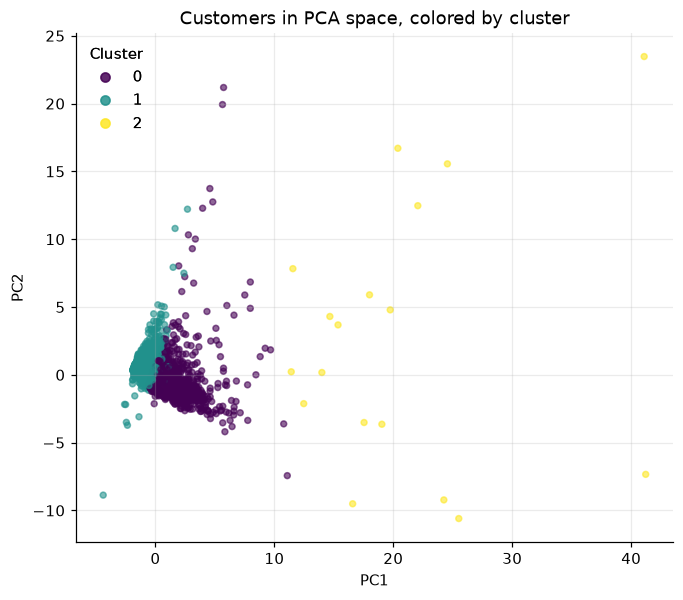

component 1 explains 32.03%
component 2 explains 15.08%
together              47.11% — 52.89% of what distinguishes these customers is not on this page

saved c:\Users\ACER\AIEP_Olo_student\week_1_foundations\labs\D5_clustering_pca\artefacts\pca_2d.png


In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) PCA(n_components=2, random_state=42) on X_scaled — the scaled matrix, never the raw one.
#    PCA maximises variance, so unscaled columns would hijack it exactly as they hijacked
#    K-Means in Task 2.1.
# 2) Scatter the two components, one colour per cluster, with a legend.
# 3) Print `explained_variance_ratio_` — one number per component — and their sum.
# 4) Save the figure to ARTEFACT_DIR / "pca_2d.png" with fig.savefig. Never write a literal
#    path: ARTEFACT_DIR resolves correctly on a laptop and on Colab.
# Search: "sklearn PCA explained_variance_ratio_ scatter clusters"
#
# ١) استخدم PCA(n_components=2, random_state=42) على X_scaled — المصفوفة الموحّدة لا الخام.
#    فـPCA تعظّم التباين، والأعمدة غير الموحّدة ستخطفها تمامًا كما خطفت K-Means في المهمة ٢٫١.
# ٢) انثر المكوّنين بلون لكل عنقود
#    مع مفتاح للرسم.
# ٣) اطبع `explained_variance_ratio_` — رقم لكل مكوّن — ومجموعهما.
# ٤) احفظ الشكل في ARTEFACT_DIR / "pca_2d.png" بـfig.savefig. ولا تكتب مسارًا صريحًا أبدًا:
#    فـARTEFACT_DIR يُحلّ صحيحًا على الحاسوب المحلي وعلى Colab.
# ابحث عن: "sklearn PCA explained_variance_ratio_ scatter clusters"
# ────────────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    coordinates[:, 0], coordinates[:, 1],
    c=final_labels, cmap="viridis", alpha=0.6, s=15
)
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Customers in PCA space, colored by cluster")

pca_path = ARTEFACT_DIR / "pca_2d.png"
fig.savefig(pca_path, dpi=150, bbox_inches="tight")
plt.show()


# TODO: Project X_scaled to 2 components, scatter it coloured by cluster, save it to ARTEFACT_DIR / "pca_2d.png", and report the explained variance.
# مهمة: أسقِط X_scaled على مكوّنين، وانثره ملوّنًا بحسب العنقود، واحفظه في ARTEFACT_DIR / "pca_2d.png"، واذكر التباين المفسَّر.
explained = pca.explained_variance_ratio_
print(f"component 1 explains {explained[0]:.2%}")
print(f"component 2 explains {explained[1]:.2%}")
print(f"together              {explained.sum():.2%} — "
      f"{1 - explained.sum():.2%} of what distinguishes these customers is not on this page")
print(f"\nsaved {pca_path}")

The two components carry 47% of the variance between them. The other 53% is not on the page.

That matters in both directions, and students usually only hear one of them. If two clusters look
separated in this picture, they really are separated — you cannot manufacture separation by projecting.
But if two clusters look **overlapping**, that is not evidence that they overlap; they may be cleanly
apart along a direction this projection threw away. A 2-D PCA plot can prove separation and cannot
disprove it.

So the picture is worth showing, and it is not worth arguing from. The argument in Task 2.4 came from
the profile table, in pounds and days, and it would have been just as strong with no picture at all.

<div dir="rtl" align="right">

يحمل المكوّنان معًا ٤٧٪ من التباين. والباقي ٥٣٪ ليس على الصفحة.

وهذا مهم في الاتجاهين، ولا يسمع الطلاب عادةً إلا أحدهما. فإن بدا عنقودان متباعدين في هذه الصورة فهما
متباعدان فعلًا — إذ لا يمكن تصنيع التباعد بالإسقاط. أما إن بدا عنقودان **متداخلين** فليس ذلك دليلًا على
تداخلهما؛ فقد يكونان منفصلين تمامًا في اتجاه أهمله هذا الإسقاط. فمخطّط PCA ثنائي البعد يستطيع إثبات
التباعد ولا يستطيع نفيه.

فالصورة تستحق العرض ولا تستحق الاحتجاج بها. أما الحجّة في المهمة ٢٫٤ فجاءت من جدول الملامح بالجنيهات
والأيام، وكانت ستبقى بالقوّة نفسها دون أي صورة.

</div>

## Section 3 — Stretch: name them, and say what would change your mind  (≈30 min)

Open-ended, and lower expectation of completeness. This is where today's skill meets your capstone.

Give each of your clusters a name a marketing team would actually use, and write the one-line
description you would put next to it in a deck. Then answer the harder question: **what would you need
in order to know whether these segments are real?**

That second question is the one with no code in it, and it is the one that separates a segmentation from
a colouring exercise. Some starting points: what happens to the clusters if you change the random seed?
If you cluster last year's data and this year's separately, do the same groups appear? If you had a
label — who responded to a campaign, who churned — would the clusters predict it?

**Link to your capstone:** if your project has no labels, this is the shape your entire evaluation will
take. You will not be able to report accuracy, and you will have to convince someone anyway.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: سمِّها وقل ما الذي يغيّر رأيك (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل. هنا تلتقي مهارة اليوم بمشروع تخرّجك.

أعطِ كل عنقود اسمًا يستخدمه فريق تسويق فعلًا، واكتب السطر الوصفي الذي ستضعه بجواره في عرض تقديمي. ثم
أجب عن السؤال الأصعب: **ما الذي تحتاجه لتعرف هل هذه القطاعات حقيقية؟**

هذا السؤال الثاني هو الذي لا شيفرة فيه، وهو الذي يفصل بين التقسيم وبين تلوين الرسوم. ومن نقاط البداية:
ماذا يحدث للعناقيد إن غيّرت البذرة العشوائية؟ وإن جمّعت بيانات العام الماضي وهذا العام كلًّا على حدة، هل
تظهر المجموعات نفسها؟ ولو كانت لديك تسمية — من استجاب لحملة، ومن غادر — فهل تتنبّأ بها العناقيد؟

**الصلة بمشروعك:** إن كان مشروعك بلا تسميات فهذا هو شكل تقييمك كلّه. لن تستطيع ذكر الدقّة، وسيلزمك إقناع
أحدهم على أي حال.

</div>

In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) The cheapest reality check is stability: re-fit with two or three different
#    random_state values and see whether the cluster sizes and profiles survive.
# 2) Compare the assignments, not just the sizes — cluster numbering is arbitrary, so two
#    runs can agree completely and still label the same group 0 and 2.
# 3) adjusted_rand_score compares two labellings while ignoring the numbering. 1.0 means
#    identical grouping.
# 4) Then write your names and your answer in the markdown cell below.
# Search: "sklearn adjusted_rand_score compare clusterings"
#
# ١) أرخص فحص للواقع هو الثبات: أعِد التدريب بقيمتين أو ثلاث مختلفة لـrandom_state وانظر هل
#    تصمد أحجام العناقيد وملامحها.
# ٢) قارن الإسنادات لا الأحجام فقط — فترقيم العناقيد اعتباطي، وقد يتّفق تشغيلان تمامًا بينما
#    يسمّي أحدهما المجموعة نفسها ٠ والآخر ٢.
# ٣) تقارن adjusted_rand_score تسميتين متجاهلةً الترقيم. والقيمة ١٫٠ تعني تجميعًا متطابقًا.
# ٤) ثم اكتب أسماءك وإجابتك
#    في خلية النص التالية.
# ابحث عن: "sklearn adjusted_rand_score compare clusterings"
# ────────────────────────────────────────────────────────────────────

# TODO: Re-cluster with two other random seeds and measure whether the grouping survives.
# مهمة: أعِد التجميع ببذرتين عشوائيتين أخريين وقِس هل يصمد التجميع.

from sklearn.metrics import adjusted_rand_score

stability_rows = []
for seed in [7, 123]:
    km_alt = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=seed)
    labels_alt = km_alt.fit_predict(X_scaled)

    ari = adjusted_rand_score(final_labels, labels_alt)
    stability_rows.append({"random_state": seed, "adjusted_rand_index": ari})

    print(f"random_state={seed}: adjusted Rand index vs original = {ari:.4f}")

stability = pd.DataFrame(stability_rows)
print("\n", stability.to_string(index=False))


random_state=7: adjusted Rand index vs original = 1.0000
random_state=123: adjusted Rand index vs original = 1.0000

  random_state  adjusted_rand_index
            7                  1.0
          123                  1.0


Both seeds return an adjusted Rand index of 1.0000 — identical grouping, with only the cluster numbers
shuffled. That is a real result and it is worth stating plainly: at `k = 3` the answer does not depend on
where K-Means started, so the one objection you can cheaply rule out is ruled out.

Be careful what you conclude from it. Stability says the algorithm finds the same split every time. It
does not say the split is meaningful, and it does not say it would survive on next year's customers. It
is the first of the questions below, not the answer to them.

<div dir="rtl" align="right">

تعطي البذرتان معامل راند المعدَّل ١٫٠٠٠٠ — تجميع متطابق، ولم يتغيّر إلا ترقيم العناقيد. وهذه نتيجة حقيقية
تستحق القول صراحةً: عند `k = 3` لا تتوقّف الإجابة على نقطة انطلاق K-Means، فالاعتراض الوحيد الذي يمكن
استبعاده بثمن زهيد قد استُبعد.

وانتبه لما تستنتجه منها. فالثبات يقول إن الخوارزمية تجد التقسيم نفسه في كل مرة. ولا يقول إن التقسيم ذو
معنى، ولا إنه سيصمد على عملاء العام القادم. إنه أول الأسئلة أدناه لا إجابتها.

</div>

**Your answer:** _(name each cluster, one line of description each. Then: what would you need in order
to know whether these segments are real? Name at least one thing you could actually do next week, and
one thing you would need data you do not have.)_

<div dir="rtl" align="right">

**إجابتك:** _(سمِّ كل عنقود بسطر وصفي واحد. ثم: ما الذي تحتاجه لتعرف هل هذه القطاعات حقيقية؟ اذكر شيئًا
واحدًا على الأقل تستطيع فعله الأسبوع القادم، وشيئًا واحدًا يلزمه بيانات لا تملكها.)_

</div>

## Save your artefacts

Two files today. `segments.parquet` holds one row per customer — their id, their cluster, and the
original feature values, so the profile table can be rebuilt from it without re-running the clustering.
`pca_2d.png` you already saved in Task 2.5.

Unlike every other artefact this week, `segments.parquet` is not a number someone could check. It is a
claim. The sentences you wrote in Task 2.4 are what makes it a deliverable rather than a column of
integers.

<div dir="rtl" align="right">

## احفظ مخرجاتك

ملفّان اليوم. يحمل `segments.parquet` صفًا لكل عميل — معرّفه وعنقوده وقيم خصائصه الأصلية — ليمكن إعادة
بناء جدول الملامح منه دون إعادة تشغيل التجميع. أما `pca_2d.png` فقد حفظته في المهمة ٢٫٥.

وخلافًا لكل مخرجات هذا الأسبوع، ليس `segments.parquet` رقمًا يستطيع أحد التحقّق منه. إنه دعوى. والجُمل
التي كتبتها في المهمة ٢٫٤ هي ما يجعله مُخرَجًا لا عمودًا من الأعداد الصحيحة.

</div>

In [11]:
segments = customers.assign(cluster=final_labels)

out = ARTEFACT_DIR / "segments.parquet"
segments.to_parquet(out, index=False)
print(f"Saved {out}  ({len(segments):,} rows, one per customer)")
print(f"Saved {ARTEFACT_DIR / 'pca_2d.png'}")
print()
print(segments[["customer_id", "cluster", "n_orders", "total_spend", "recency_days"]]
      .head(5).to_string(index=False))

Saved c:\Users\ACER\AIEP_Olo_student\week_1_foundations\labs\D5_clustering_pca\artefacts\segments.parquet  (4,372 rows, one per customer)
Saved c:\Users\ACER\AIEP_Olo_student\week_1_foundations\labs\D5_clustering_pca\artefacts\pca_2d.png

 customer_id  cluster  n_orders  total_spend  recency_days
       12346        1         2         0.00           325
       12347        0         7      4310.00             2
       12348        0         4      1797.24            75
       12349        1         1      1757.55            18
       12350        1         1       334.40           310


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

Note what these checks can and cannot do. They can confirm that the raw clustering collapsed and the
scaled one did not, that you scored every `k`, and that your files exist. **No check here can tell you
your `k` was a good choice** — that is what the writing is for, and why a TA reads it.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

ولاحظ ما تستطيعه هذه الفحوص وما لا تستطيعه. تستطيع تأكيد أن التجميع الخام انهار وأن الموحّد لم ينهر،
وأنك قيّمت كل `k`، وأن ملفاتك موجودة. **ولا يستطيع أي فحص هنا أن يخبرك أن اختيارك لـ`k` كان صائبًا** —
فلذلك وُجدت الكتابة، ولذلك يقرؤها مساعد التدريس.

</div>

In [12]:
# --- Sanity checks ----------------------------------------------------------------

check(raw_biggest_share > 0.90,
      f"clustering the raw columns should collapse into one giant cluster — that is the lesson of "
      f"Task 2.1. Biggest cluster is {raw_biggest_share:.2%}, expected above 90%",
      f"يجب أن ينهار تجميع الأعمدة الخام في عنقود واحد ضخم — وهذا درس المهمة ٢٫١. أكبر عنقود "
      f"{raw_biggest_share:.2%} والمتوقّع فوق ٩٠٪")

check(scaled_biggest_share < 0.75,
      f"after standardising, no cluster should hold three quarters of the customers; the biggest "
      f"holds {scaled_biggest_share:.2%}. If it is still above 90%, you clustered the raw matrix again",
      f"بعد التوحيد القياسي يجب ألّا يضمّ أي عنقود ثلاثة أرباع العملاء، وأكبرها يضمّ "
      f"{scaled_biggest_share:.2%}. فإن بقي فوق ٩٠٪ فقد جمّعت المصفوفة الخام مرة أخرى")

check(scaled_biggest_share < raw_biggest_share - 0.20,
      f"standardising should visibly reduce the dominance of the biggest cluster: "
      f"{raw_biggest_share:.2%} raw vs {scaled_biggest_share:.2%} scaled",
      f"يجب أن يقلّل التوحيد القياسي هيمنة أكبر عنقود بوضوح: {raw_biggest_share:.2%} خام مقابل "
      f"{scaled_biggest_share:.2%} موحّد")

check(len(k_scores) == len(list(K_RANGE)) and k_scores["silhouette"].notna().all(),
      f"you need a silhouette score for every k in {list(K_RANGE)}, got {len(k_scores)} rows",
      f"تحتاج معامل ظلّ لكل k في {list(K_RANGE)}، والعدد {len(k_scores)} صفًا")

check(len(segments) == len(customers) and segments["customer_id"].is_unique,
      f"segments.parquet must have exactly one row per customer ({len(customers):,}), "
      f"got {len(segments):,} rows with "
      f"{segments['customer_id'].nunique():,} distinct ids",
      f"يجب أن يحتوي segments.parquet صفًا واحدًا لكل عميل ({len(customers):,})، والعدد "
      f"{len(segments):,} صفًا بـ{segments['customer_id'].nunique():,} معرّفًا مختلفًا")

check(coordinates.shape == (len(customers), 2),
      f"the PCA projection should be one 2-column row per customer, got {coordinates.shape}",
      f"يجب أن يكون إسقاط PCA صفًا بعمودين لكل عميل، والشكل {coordinates.shape}")

check(0.20 < explained.sum() < 0.95,
      f"record the explained variance and read it: two components carry {explained.sum():.2%} of "
      f"the variance in twelve columns",
      f"سجّل التباين المفسَّر واقرأه: يحمل المكوّنان {explained.sum():.2%} من التباين في اثني عشر عمودًا")

check((ARTEFACT_DIR / "segments.parquet").exists() and (ARTEFACT_DIR / "pca_2d.png").exists(),
      "both segments.parquet and pca_2d.png should exist — run the save cells above",
      "يجب أن يوجد الملفان segments.parquet وpca_2d.png — شغّل خليتَي الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  clustering the raw columns should collapse into one giant cluster — that is the lesson of Task 2.1. Biggest cluster is 99.15%, expected above 90%
  ✓  after standardising, no cluster should hold three quarters of the customers; the biggest holds 59.86%. If it is still above 90%, you clustered the raw matrix again
  ✓  standardising should visibly reduce the dominance of the biggest cluster: 99.15% raw vs 59.86% scaled
  ✓  you need a silhouette score for every k in [2, 3, 4, 5, 6, 7, 8, 9, 10], got 9 rows
  ✓  segments.parquet must have exactly one row per customer (4,372), got 4,372 rows with 4,372 distinct ids
  ✓  the PCA projection should be one 2-column row per customer, got (4372, 2)
  ✓  record the explained variance and read it: two components carry 47.11% of the variance in twelve columns
  ✓  both segments.parquet and pca_2d.png should exist — run the save cells above
─────────────────────────────────────

## What's next

Week 1 is done: you have trained, evaluated, and now grouped. Week 2 starts with pandas properly, and
W2D4 gives you the transform that would have fixed the skew you diagnosed today.

<div dir="rtl" align="right">

## ماذا بعد

انتهى الأسبوع الأول: درّبت وقيّمت والآن جمّعت. ويبدأ الأسبوع الثاني بـpandas على وجهها، ويعطيك الأسبوع ٢
اليوم ٤ التحويل الذي كان سيصلح الالتواء الذي شخّصته اليوم.

</div>